# 02. Date and Time
In the class notebook *DateTime (Bike Rental)* the text column `datetime` was turned into real dates with `to_datetime`, and the year, month and day were taken out with `.dt.year`, `.dt.month`… We do the same with our dates.

* **Needs:** `ISEQ.csv`. **Makes:** nothing new.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [2]:
from pandas import read_csv
data1 = read_csv(folder + 'ISEQ.csv')
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5898 entries, 0 to 5897
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5898 non-null   str    
 1   Open        5898 non-null   float64
 2   High        5898 non-null   float64
 3   Low         5898 non-null   float64
 4   Close       5898 non-null   float64
 5   Volume      5898 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 334.2 KB


The first column has no name (`Unnamed: 0`) and its type is `object` — that means **text**, not a date. First we give it a name.

In [3]:
data1 = data1.rename(columns={'Unnamed: 0': 'Date'})
data1['Date']

0       2002-10-01
1       2002-10-02
2       2002-10-03
3       2002-10-04
4       2002-10-07
           ...    
5893    2025-12-22
5894    2025-12-23
5895    2025-12-24
5896    2025-12-29
5897    2025-12-30
Name: Date, Length: 5898, dtype: str

## Change the text into dates

In [4]:
from pandas import to_datetime
data1['Date'] = to_datetime(data1['Date'])
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5898 entries, 0 to 5897
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5898 non-null   datetime64[us]
 1   Open    5898 non-null   float64       
 2   High    5898 non-null   float64       
 3   Low     5898 non-null   float64       
 4   Close   5898 non-null   float64       
 5   Volume  5898 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 276.6 KB


Now the type of `Date` is `datetime64` — a real date. So we can take out its parts, like in the Bike Rental notebook:

In [5]:
data1['year'] = data1['Date'].dt.year
data1['month'] = data1['Date'].dt.month
data1['day'] = data1['Date'].dt.day
data1['day_week'] = data1['Date'].dt.dayofweek
data1.head()

,Date,Open,High,Low,Close,Volume,year,month,day,day_week
0,2002-10-01,3838.520020,3882.870117,3813.500000,3863.100098,0,2002,10,1,1
1,2002-10-02,3864.139893,3942.629883,3859.600098,3926.350098,0,2002,10,2,2
2,2002-10-03,3926.270020,3933.560059,3871.360107,3875.959961,0,2002,10,3,3
3,2002-10-04,3875.870117,3887.030029,3840.580078,3842.899902,0,2002,10,4,4
4,2002-10-07,3843.040039,3843.040039,3736.889893,3748.659912,0,2002,10,7,0


`day_week`: 0 = Monday, 1 = Tuesday, … 4 = Friday. Let us count:

In [6]:
data1['day_week'].value_counts().sort_index()

day_week
0    1126
1    1197
2    1199
3    1200
4    1176
Name: count, dtype: int64

There is no 5 (Saturday) or 6 (Sunday): the stock market is closed at weekends. How many trading days per year?

In [7]:
data1['year'].value_counts().sort_index()

year
2002     63
2003    253
2004    254
2005    253
2006    253
2007    254
2008    254
2009    251
2010    254
2011    253
2012    254
2013    254
2014    254
2015    254
2016    254
2017    253
2018    253
2019    253
2020    256
2021    255
2022    254
2023    254
2024    255
2025    253
Name: count, dtype: int64

About 250–255 trading days per year (2002 and 2025 are not complete years in the file).

## Use the date as the index
If the date becomes the **index** (the row label), pandas can select periods with `.loc`. This is how we will choose training years, test years and crisis windows later.

In [8]:
data1 = data1.set_index('Date')
data1.head()

,Open,High,Low,Close,Volume,year,month,day,day_week
Date,,,,,,,,,
2002-10-01,3838.520020,3882.870117,3813.500000,3863.100098,0,2002,10,1,1
2002-10-02,3864.139893,3942.629883,3859.600098,3926.350098,0,2002,10,2,2
2002-10-03,3926.270020,3933.560059,3871.360107,3875.959961,0,2002,10,3,3
2002-10-04,3875.870117,3887.030029,3840.580078,3842.899902,0,2002,10,4,4
2002-10-07,3843.040039,3843.040039,3736.889893,3748.659912,0,2002,10,7,0


### Example 1: the week of the Irish bank guarantee (30 September 2008)

In [9]:
data1.loc['2008-09-26':'2008-10-02', ['Close']]

,Close
Date,
2008-09-26,3784.770020
2008-09-29,3291.520020
2008-09-30,3550.629883
2008-10-01,3641.290039
2008-10-02,3822.939941


On 29 September 2008 the ISEQ fell from 3,785 to 3,292 (about −13%). The next day the Irish government guaranteed the banks, and the market jumped back.

### Example 2: COVID-19, March 2020

In [10]:
data1.loc['2020-03-09':'2020-03-13', ['Close']]

,Close
Date,
2020-03-09,5864.700195
2020-03-10,5826.649902
2020-03-11,5691.439941
2020-03-12,5125.939941
2020-03-13,5148.430176


### Example 3: a whole year

In [11]:
data1.loc['2008'].shape

(254, 9)

## A first picture

<Axes: title={'center': 'ISEQ Overall, closing price'}, xlabel='Date'>

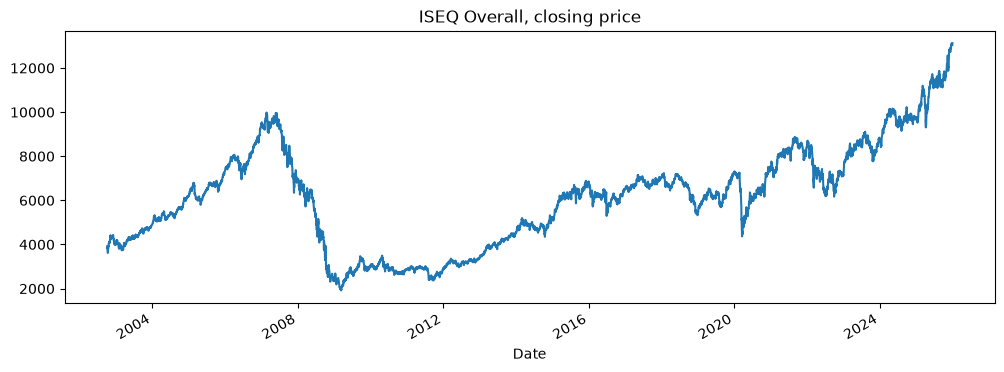

In [12]:
data1['Close'].plot(figsize=(12, 4), title='ISEQ Overall, closing price')

You can see the boom until 2007, the crash of 2008–09, and the falls in 2011, 2016, 2020 and 2022.